# 07 特徴量エンジニアリング実験

本ノートブックでは、`designs/04_feature_engineering.md` に基づき、以下の特徴量グループの追加効果を検証します。
- **Exp-A**: 曜日の円環エンコーディング
- **Exp-B**: Days_to_MPM の円環エンコーディング
- **Exp-C**: カーブ形状（Slope・Butterfly）の水準と変化速度
- **Exp-ABC**: 全部のせ

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from src.processing import load_and_clean_data
from src.features import generate_features
from src.pooling import pool_boj_data
from src.modeling import walk_forward_validation, calculate_metrics

EXCEL_PATH = "../data/BOJ_data.xlsx"
MEETING_CSV_PATH = "../data/BOJ_meeting_history.csv"
START_DATE = "2024-01-01"

# データの読み込み
df_raw = load_and_clean_data(EXCEL_PATH, MEETING_CSV_PATH)

## 実験の実行定義

In [2]:
def run_experiment(df_raw, label, **feat_kwargs):
    print(f"Running {label}...")
    df_feat = generate_features(df_raw, **feat_kwargs)
    df_pooled = pool_boj_data(df_feat)
    
    # 3d 予測
    res_3d = walk_forward_validation(df_pooled, "Target_3d", START_DATE)
    metrics_3d = calculate_metrics(res_3d["Actual"], res_3d["Pred"])
    
    # 5d 予測
    res_5d = walk_forward_validation(df_pooled, "Target_5d", START_DATE)
    metrics_5d = calculate_metrics(res_5d["Actual"], res_5d["Pred"])
    
    print(f"  {label}: IC_3d={metrics_3d['IC']:.4f}, IC_5d={metrics_5d['IC']:.4f}")
    return metrics_3d["IC"], metrics_5d["IC"]

## 各実験の実行

In [3]:
results = []

# Baseline
ic_3d, ic_5d = run_experiment(df_raw, "Baseline")
results.append({"Experiment": "Baseline", "IC_3d": ic_3d, "IC_5d": ic_5d})

# Exp-A (Weekday)
ic_3d, ic_5d = run_experiment(df_raw, "Exp-A (Weekday)", add_weekday_cyclic=True)
results.append({"Experiment": "Exp-A", "IC_3d": ic_3d, "IC_5d": ic_5d})

# Exp-B (DTM cyclic)
ic_3d, ic_5d = run_experiment(df_raw, "Exp-B (DTM cyclic)", add_days_to_mpm_cyclic=True)
results.append({"Experiment": "Exp-B", "IC_3d": ic_3d, "IC_5d": ic_5d})

# Exp-C (Curve)
ic_3d, ic_5d = run_experiment(df_raw, "Exp-C (Curve)", add_curve_features=True)
results.append({"Experiment": "Exp-C", "IC_3d": ic_3d, "IC_5d": ic_5d})

# Exp-ABC (All)
ic_3d, ic_5d = run_experiment(df_raw, "Exp-ABC (All)", 
                              add_weekday_cyclic=True, 
                              add_days_to_mpm_cyclic=True, 
                              add_curve_features=True)
results.append({"Experiment": "Exp-ABC", "IC_3d": ic_3d, "IC_5d": ic_5d})

Running Baseline...
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[1]	train's rmse: 0.0200739	valid's rmse: 0.0254237
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[160]	train's rmse: 0.00799131	valid's rmse: 0.0176654
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[32]	train's rmse: 0.0124954	valid's rmse: 0.0232448
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[8]	train's rmse: 0.0177649	valid's rmse: 0.0265422
Training until validation scores don't improve for 100 rounds


...

Early stopping, best iteration is:
[13]	train's rmse: 0.019195	valid's rmse: 0.0330971
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[65]	train's rmse: 0.0117198	valid's rmse: 0.0291049
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[513]	train's rmse: 0.00449129	valid's rmse: 0.0596929
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[2]	train's rmse: 0.0339081	valid's rmse: 0.0324307
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[7]	train's rmse: 0.0293225	valid's rmse: 0.0398528
  Exp-ABC (All): IC_3d=0.2491, IC_5d=0.2681


## 結果の比較

In [4]:
df_results = pd.DataFrame(results)
baseline_ic_3d = df_results.loc[df_results["Experiment"] == "Baseline", "IC_3d"].values[0]
baseline_ic_5d = df_results.loc[df_results["Experiment"] == "Baseline", "IC_5d"].values[0]

df_results["Delta_IC_3d"] = df_results["IC_3d"] - baseline_ic_3d
df_results["Delta_IC_5d"] = df_results["IC_5d"] - baseline_ic_5d

print("### 実験結果一覧 ###")
print(df_results.to_string(index=False))

### 実験結果一覧 ###
Experiment    IC_3d    IC_5d  Delta_IC_3d  Delta_IC_5d
  Baseline 0.285992 0.245824     0.000000     0.000000
     Exp-A 0.234830 0.280002    -0.051162     0.034177
     Exp-B 0.321278 0.279983     0.035286     0.034159
     Exp-C 0.218026 0.272529    -0.067966     0.026705
   Exp-ABC 0.249078 0.268083    -0.036914     0.022259


## 特徴量重要度の確認 (Exp-C)

--- Exp-C Feature Importance (3d) ---
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[10]	train's rmse: 0.0167446	valid's rmse: 0.024462
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[85]	train's rmse: 0.00975954	valid's rmse: 0.0202999
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[16]	train's rmse: 0.0151082	valid's rmse: 0.0235173
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[2]	train's rmse: 0.0204588	valid's rmse: 0.0268707
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[21]	train's rmse: 0.0143876	valid's rmse: 0.0226478
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[10]	train's rmse: 0.0177606	valid's rmse: 0.0241094
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[184]	train's rmse: 0.00762283	valid's rmse: 0.047854
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[4]	train's rmse: 0.0259018	valid's rmse: 0.0242186
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[2]	train's rmse: 0.0267923	valid's rmse: 0.0326551


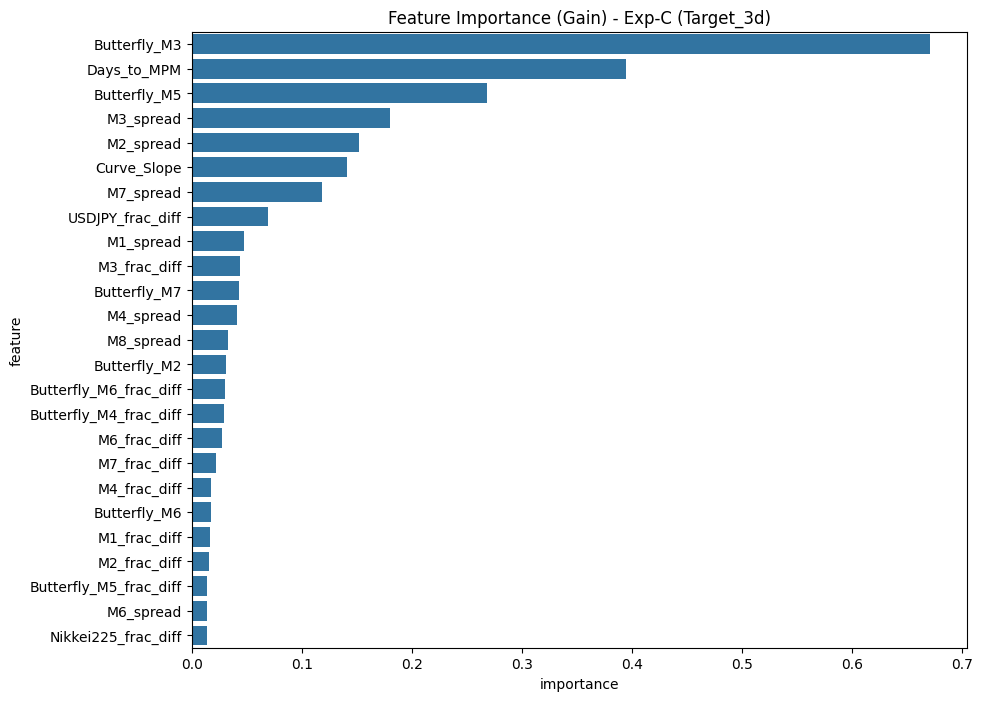

             feature  importance
32      Butterfly_M3    0.670915
1        Days_to_MPM    0.394769
34      Butterfly_M5    0.268504
5          M3_spread    0.180002
4          M2_spread    0.151995
30       Curve_Slope    0.140992
9          M7_spread    0.118457
27  USDJPY_frac_diff    0.069068
3          M1_spread    0.047634
13      M3_frac_diff    0.043565
--- Exp-C Feature Importance (5d) ---
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[3]	train's rmse: 0.0234216	valid's rmse: 0.0210464
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[10]	train's rmse: 0.0198679	valid's rmse: 0.0194804
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[7]	train's rmse: 0.0208714	valid's rmse: 0.0239325
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[1]	train's rmse: 0.0246483	valid's rmse: 0.0301036
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[23]	train's rmse: 0.0163481	valid's rmse: 0.0322543
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[80]	train's rmse: 0.0108467	valid's rmse: 0.0308071
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[130]	train's rmse: 0.00973057	valid's rmse: 0.0610307
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[4]	train's rmse: 0.0320961	valid's rmse: 0.0319025
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[91]	train's rmse: 0.012536	valid's rmse: 0.0392871


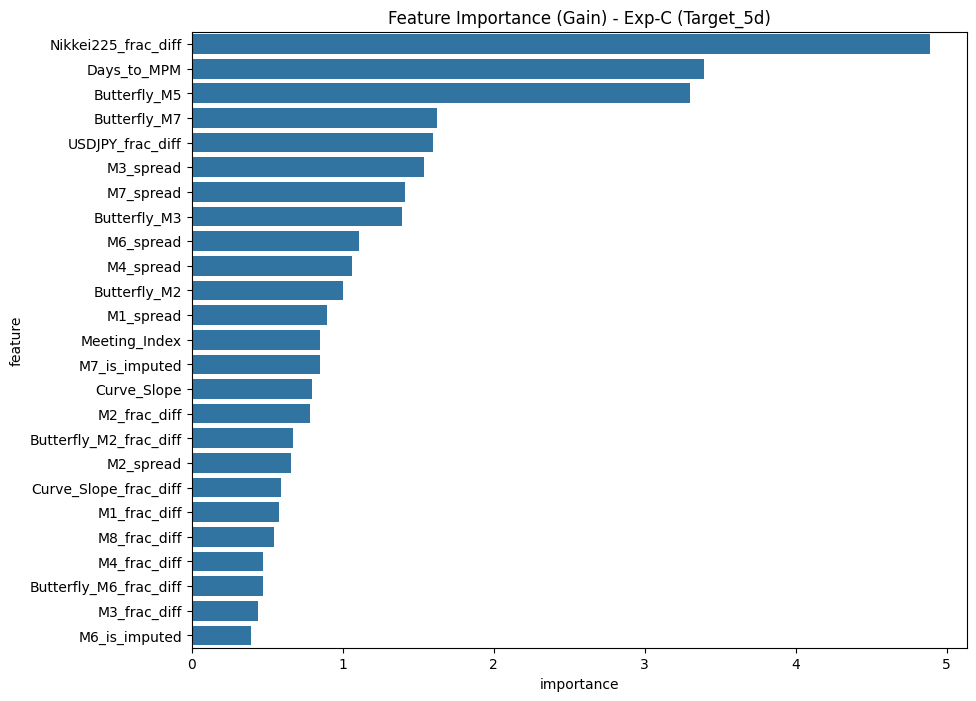

                feature  importance
29  Nikkei225_frac_diff    4.888034
1           Days_to_MPM    3.393133
34         Butterfly_M5    3.302214
36         Butterfly_M7    1.627343
27     USDJPY_frac_diff    1.600381
5             M3_spread    1.535484
9             M7_spread    1.413143
32         Butterfly_M3    1.394330
8             M6_spread    1.108044
6             M4_spread    1.062433


In [5]:
def plot_importance(df_raw, target_col, label, **feat_kwargs):
    df_feat = generate_features(df_raw, **feat_kwargs)
    df_pooled = pool_boj_data(df_feat)
    
    # return_model=True で最終フォールドを取得
    res, model, X_test, y_test, X_train = walk_forward_validation(
        df_pooled, target_col, START_DATE, return_model=True
    )
    
    importance = pd.DataFrame({
        "feature": X_test.columns,
        "importance": model.feature_importance(importance_type="gain")
    }).sort_values("importance", ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x="importance", y="feature", data=importance.head(25))
    plt.title(f"Feature Importance (Gain) - {label} ({target_col})")
    plt.show()
    
    return importance.head(10)

print("--- Exp-C Feature Importance (3d) ---")
imp_3d = plot_importance(df_raw, "Target_3d", "Exp-C", add_curve_features=True)
print(imp_3d)

print("--- Exp-C Feature Importance (5d) ---")
imp_5d = plot_importance(df_raw, "Target_5d", "Exp-C", add_curve_features=True)
print(imp_5d)